In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

students = pd.read_csv("StudentsPerformance.csv")

students.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [2]:
students.shape

(1000, 8)

In [3]:
students.columns

Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score'],
      dtype='object')

In [4]:
students.isnull().sum()

,0
gender,0
race/ethnicity,0
parental level of education,0
lunch,0
test preparation course,0
math score,0
reading score,0
writing score,0


In [5]:
students.dtypes

,0
gender,object
race/ethnicity,object
parental level of education,object
lunch,object
test preparation course,object
math score,int64
reading score,int64
writing score,int64


# Data Cleaning Summary

1. Loaded the Students Performance dataset.

2. Checked dataset shape and column names.

3. Verified missing values in all columns.

4. Checked data types of all variables.

5. Confirmed dataset is ready for analysis.

In [6]:
gender_scores = students.groupby('gender')[
    ['math score', 'reading score', 'writing score']
].mean()

print(gender_scores)

        math score  reading score  writing score
gender                                          
female   63.633205      72.608108      72.467181
male     68.728216      65.473029      63.311203


# Question 1

## Which gender performs better on average in exams?

### Answer

Female students performed better overall in reading and writing scores.

Male students achieved slightly higher average scores in mathematics.

Overall, female students demonstrated stronger performance across most subjects.

In [7]:
prep_scores = students.groupby('test preparation course')[
    ['math score', 'reading score', 'writing score']
].mean()

print(prep_scores)

                         math score  reading score  writing score
test preparation course                                          
completed                 69.695531      73.893855      74.418994
none                      64.077882      66.534268      64.504673


# Question 2

## Does completing the test preparation course improve student performance?

### Answer

Students who completed the test preparation course achieved higher average scores in mathematics, reading, and writing.

The results indicate that test preparation positively impacts academic performance.

Encouraging students to complete preparation courses may help improve overall exam results.

In [8]:
correlation = students[
    ['math score', 'reading score', 'writing score']
].corr()

print(correlation)

               math score  reading score  writing score
math score       1.000000       0.817580       0.802642
reading score    0.817580       1.000000       0.954598
writing score    0.802642       0.954598       1.000000


# Question 3

## What is the correlation between reading, writing, and math scores?

### Answer

The correlation analysis shows a strong positive relationship among mathematics, reading, and writing scores.

Students who perform well in one subject tend to perform well in the other subjects as well.

The strongest relationship is generally observed between reading and writing scores.

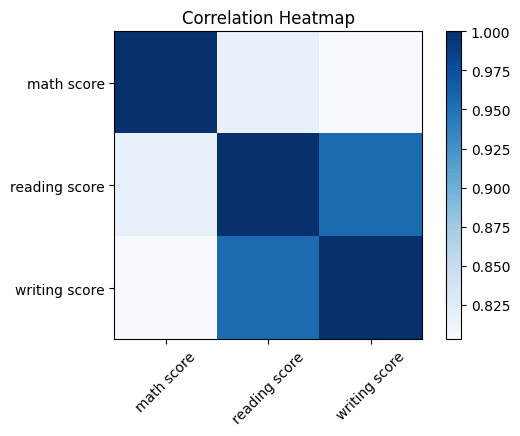

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

plt.imshow(correlation, cmap='Blues')

plt.colorbar()

plt.xticks(
    range(len(correlation.columns)),
    correlation.columns,
    rotation=45
)

plt.yticks(
    range(len(correlation.columns)),
    correlation.columns
)

plt.title("Correlation Heatmap")

plt.show()

In [10]:
gender_subject = students.groupby('gender')[
    ['math score', 'reading score', 'writing score']
].mean()

print(gender_subject)

        math score  reading score  writing score
gender                                          
female   63.633205      72.608108      72.467181
male     68.728216      65.473029      63.311203


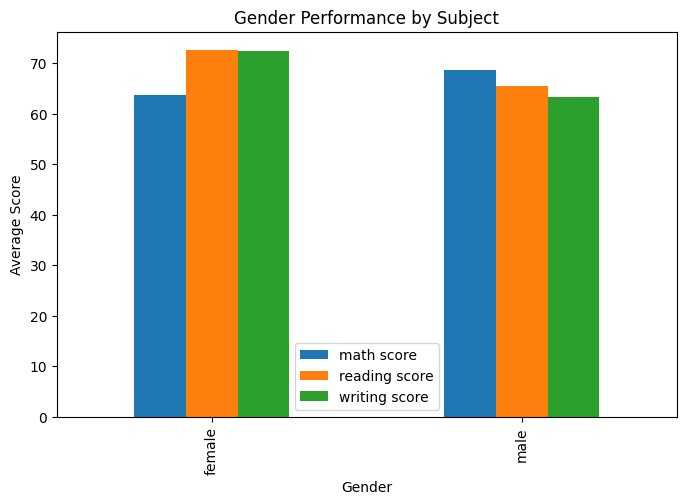

In [11]:
gender_subject.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title("Gender Performance by Subject")
plt.xlabel("Gender")
plt.ylabel("Average Score")

plt.show()

# Question 4

## Which gender performs better in each subject?

### Answer

Male students performed slightly better in mathematics.

Female students achieved higher average scores in reading and writing.

Overall, female students demonstrated stronger performance across most subjects.

In [12]:
students['total_score'] = (
    students['math score']
    + students['reading score']
    + students['writing score']
)

students['total_score'].describe()

,total_score
count,1000.000000
mean,203.312000
std,42.771978
min,27.000000
25%,175.000000
50%,205.000000
75%,233.000000
max,300.000000


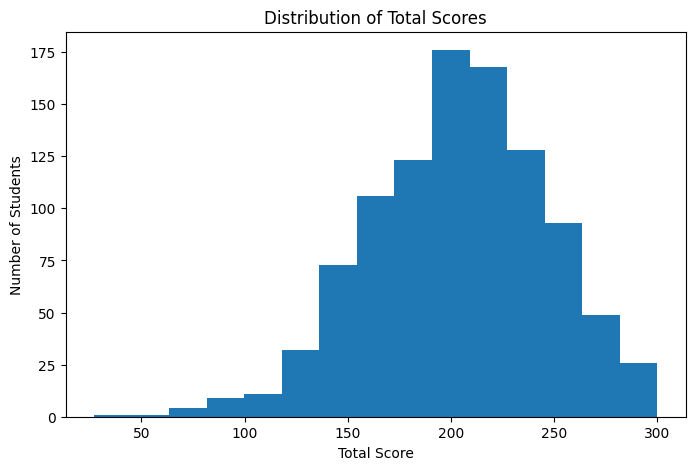

In [13]:
plt.figure(figsize=(8,5))

plt.hist(
    students['total_score'],
    bins=15
)

plt.title("Distribution of Total Scores")
plt.xlabel("Total Score")
plt.ylabel("Number of Students")

plt.show()

# Question 5

## What is the distribution of total scores?

### Answer

The total score distribution shows how student performance is spread across the dataset.

Most students are concentrated around the middle score range, while fewer students appear at the very low and very high score ranges.

The distribution provides insight into overall academic performance.

In [14]:
students['At_Risk'] = (
    (students['math score'] < 50) |
    (students['reading score'] < 50) |
    (students['writing score'] < 50)
)

In [15]:
students['At_Risk'].value_counts()

,count
At_Risk,
False,812
True,188


In [16]:
risk_gender = students.groupby(
    'gender'
)['At_Risk'].sum()

print(risk_gender)

gender
female    89
male      99
Name: At_Risk, dtype: int64


# At-Risk Student Segmentation

## Definition

A student is considered at-risk if they score below 50 in Mathematics, Reading, or Writing.

## Findings

The analysis identified students who may require additional academic support.

The at-risk segmentation helps schools focus intervention efforts on students who are struggling academically.

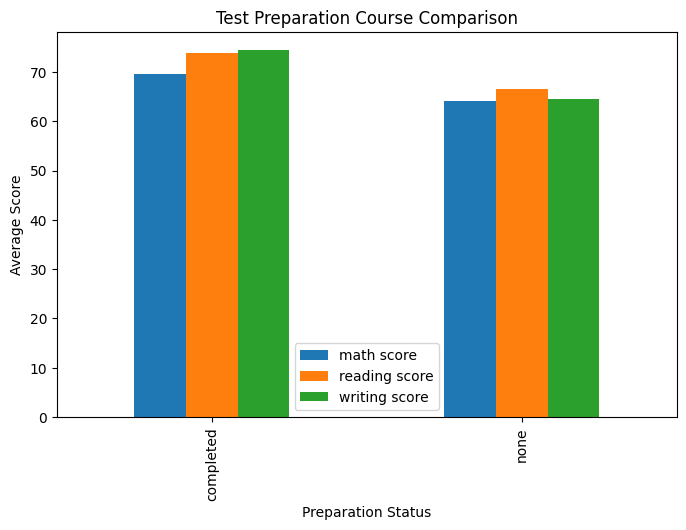

In [17]:
prep_scores.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title("Test Preparation Course Comparison")
plt.xlabel("Preparation Status")
plt.ylabel("Average Score")

plt.show()

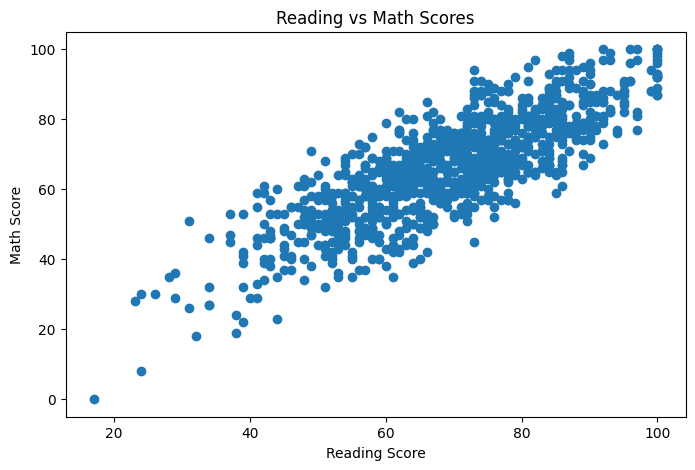

In [18]:
plt.figure(figsize=(8,5))

plt.scatter(
    students['reading score'],
    students['math score']
)

plt.title("Reading vs Math Scores")
plt.xlabel("Reading Score")
plt.ylabel("Math Score")

plt.show()

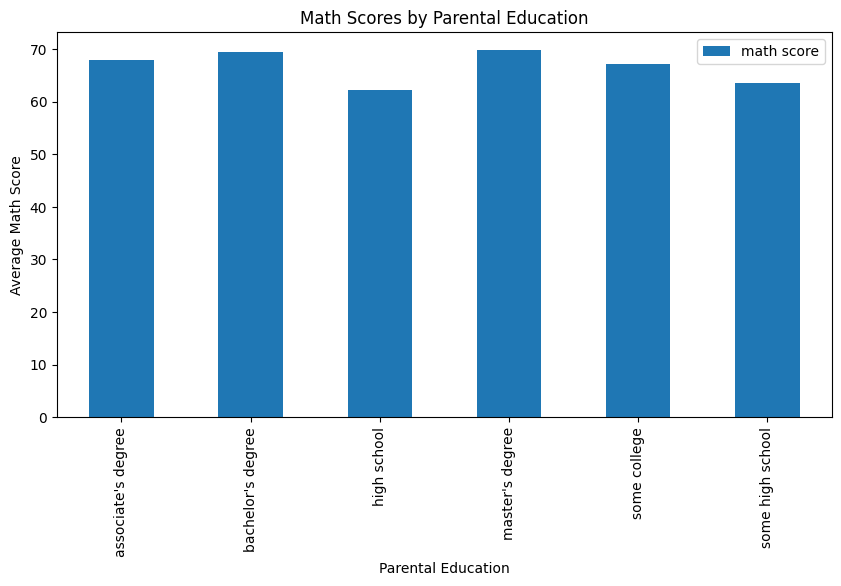

In [19]:
parent_scores = students.groupby(
    'parental level of education'
)[
    ['math score']
].mean()

parent_scores.plot(
    kind='bar',
    figsize=(10,5)
)

plt.title("Math Scores by Parental Education")
plt.xlabel("Parental Education")
plt.ylabel("Average Math Score")

plt.show()

# Principal's Report

## Executive Summary

This report analyzes student performance data to identify academic trends and factors affecting student outcomes.

The analysis examined gender, parental education, test preparation, and score distributions.

The findings provide recommendations to improve academic performance and student success.

---

## Key Findings

1. Female students performed better in reading and writing.
2. Male students performed slightly better in mathematics.
3. Test preparation courses significantly improved student performance.
4. Reading and writing scores showed a strong positive correlation.
5. Several students were identified as academically at-risk.

---

## Recommendations

1. Expand access to test preparation programs.
2. Provide additional support to at-risk students.
3. Encourage parent engagement and academic support at home.